# Searching and downloading CSDA data

[NASA's](https://www.nasa.gov/) [Commercial Satellite Data Acquisition (CSDA)](https://www.earthdata.nasa.gov/about/csda) program acquires, catalogs, and provides commercial satellite data for the scientific community.
The program's services include a [SpatioTemporal Asset Catalog](https://stacspec.org/) API server for searching and discovering CSDA assets.
We'll use [pystac-client](https://github.com/stac-utils/pystac-client) to search the CSDA STAC API for items that we can use.
The CSDA STAC API is public and open, meaning that we don't need any authorization or authentication to use it.

Before getting started, we import all the Python packages, classes, and functions that we need, and define a few helpful constants.

In [1]:
import getpass
from pathlib import Path
from tempfile import TemporaryDirectory

import contextily
import cql2
import humanize
import rasterio
import rasterio.plot
import tabulate
from geopandas import GeoDataFrame
from httpx import BasicAuth
from pystac_client import Client

from csda_client import CsdaClient

In [2]:
PLANET_ITEM_ID = "PSScene-20250706_160525_67_24c6"
SATELLOGIC_ITEM_ID = "20251123_221219_589_SN41_L1D_SR_MS_333174"

LONGMONT_CO_USA = {"type": "Point", "coordinates": [-105.1019, 40.1672]}
STEWART_NEVADA_USA = {
    "type": "Point",
    "coordinates": [-114.39874274521466, 36.349580984447435],
}

## Collection search

CSDA includes data from several [vendors](https://www.earthdata.nasa.gov/about/csda#toc-vendors).
Each vendor maps onto a single [STAC Collection](https://github.com/radiantearth/stac-spec/blob/master/collection-spec/collection-spec.md), and we can use our STAC API to discover which vendors are available.

### Why are there warnings?

The CSDA STAC catalog currently contains some invalid STAC Collections.
We're working on updating those, and when we do, the warnings will go away.

In [3]:
stac_client = Client.open("https://csdap.earthdata.nasa.gov/stac/")
rows = []
for collection in stac_client.collection_search().collections_as_dicts():
    rows.append([collection["id"], collection.get("title")])

tabulate.tabulate(rows, headers=["collection", "title"], tablefmt="html")

/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/pystac_client/collection_search.py:121: PystacClientWarning: Unable to parse extent from collection=geooptics
  warnings.warn(
/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/pystac_client/collection_search.py:121: PystacClientWarning: Unable to parse extent from collection=capellaspace
  warnings.warn(
/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/pystac_client/collection_search.py:121: PystacClientWarning: Unable to parse extent from collection=planet
  warnings.warn(
/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/pystac_client/collection_search.py:121: PystacClientWarning: Unable to parse extent from collection=spire
  warnings.warn(
/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/pystac_client/collection_search.py:121: PystacClientWarning: Unable to parse extent from co

collection,title
geooptics,GeoOptics
capellaspace,CapellaSpace
desis,DESIS
planet,Planet
spire,Spire
umbra,Umbra
iceye,Iceye
ghgsat,GHGSat
blacksky,Blacksky
pgc-earthdem,EarthDEM


## Finding Planet data

One of the CSDA vendors, [Planet](https://www.planet.com/), collects imagery that is easy to visualize and interpret, so let's use their data for this notebook.
We can use a [STAC API search query](https://github.com/radiantearth/stac-api-spec/tree/release/v1.0.0/item-search#query-parameter-table) to narrow our request.
In this example, we'll find [STAC items](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md) that:

- are in the `planet` collection
- Have a cloud cover of less than or equal to 25%
- Were collected in 2021
- Intersect [Longmont, CO, USA](https://en.wikipedia.org/wiki/Longmont,_Colorado)

STAC search is extremely powerful — you can search by other attributes, control sorting, and use datetime intervals.
Learn more in the [pystac-client docs](https://pystac-client.readthedocs.io/en/stable/tutorials.html).

### What's the deal with the `cql2` stuff?

[cql2](https://www.ogc.org/standards/cql2/) is an [Open Geospatial Consortium](https://www.ogc.org/) standard for querying spatial data.
Our STAC API only understands `cql2-json`, but `cql2-json` can be a little awkward to write.
`cql2-text` is much more intuitive, so we write that and then convert it to `cql2-json` using [this helper package](https://github.com/developmentseed/cql2-rs/).
This should become automatic via **pystac-client** [soon](https://github.com/stac-utils/pystac-client/issues/803).

In [4]:
item_search = stac_client.search(
    collections=["planet"],
    intersects=LONGMONT_CO_USA,
    filter=cql2.parse_text("eo:cloud_cover<25").to_json(),
    datetime="2021",
)
item_collection = item_search.item_collection()
print(len(item_collection))

41


Let's visualize the items, first as a `GeoDataFrame`.

In [5]:
data_frame = GeoDataFrame.from_features(item_collection.to_dict(), crs="EPSG:4326")
data_frame.head(5)

,geometry,eo:gsd,eo:epsg,pl:rows,datetime,eo:bands,eo:azimuth,pl:columns,pl:updated,pl:origin_x,...,pl:anomalous_pixels,pl:pixel_resolution,pl:publishing_stage,pl:quality_category,pl:snow_ice_percent,pl:heavy_haze_percent,pl:light_haze_percent,pl:clear_confidence_percent,pl:visible_confidence_percent,pl:ps4b_geometry
0,"POLYGON ((-105.34272 40.22107, -105.3952 40.03...",4.0,32613.0,9524.0,2021-12-30T16:54:34.641952Z,[],101.0,13191.0,2021-12-31T03:59:48Z,466281.0,...,0,3,finalized,test,0,0,0,97,72,NaN
1,"POLYGON ((-105.46945 40.24533, -105.5246 40.05...",4.0,32613.0,9595.0,2021-12-20T17:00:46.336281Z,[],278.6,13244.0,2021-12-21T04:28:04Z,455256.0,...,0,3,finalized,standard,0,0,0,96,74,NaN
2,"POLYGON ((-105.49219 40.32051, -105.54659 40.1...",4.1,32613.0,9715.0,2021-12-01T17:44:27.408844Z,[],111.8,13382.0,2021-12-02T10:03:46Z,453429.0,...,0,3,finalized,standard,0,0,0,97,59,NaN
3,"POLYGON ((-105.22817 40.32841, -105.28215 40.1...",4.1,NaN,NaN,2021-11-28T16:54:46.363155Z,[],100.9,NaN,2022-10-27T11:45:48Z,NaN,...,0,3,finalized,standard,0,0,0,98,77,"{'type': 'Polygon', 'coordinates': [[[-105.228..."
4,"POLYGON ((-105.18108 40.18135, -105.23515 39.9...",4.0,NaN,NaN,2021-11-25T17:11:14.321045Z,[],276.5,NaN,2022-10-30T06:51:29Z,NaN,...,0,3,finalized,standard,0,0,0,99,99,NaN


Then, on a map (it's pretty noisy).

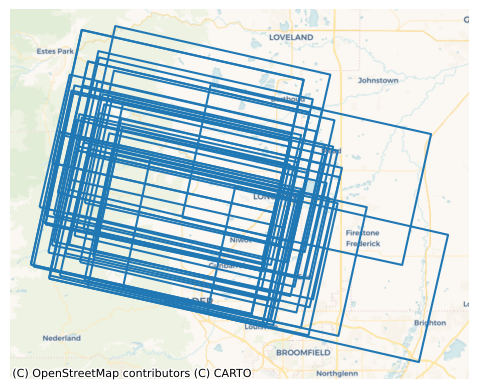

In [6]:
axes = data_frame.to_crs(epsg=3857).boundary.plot()
contextily.add_basemap(axes, source=contextily.providers.CartoDB.Voyager)
axes.set_axis_off()

If you happen to know your item (granule) id, you can fetch that item directly and see it's assets dictionary.

In [7]:
item = next(stac_client.search(collections=["planet"], ids=[PLANET_ITEM_ID]).items())
item

<Item id=PSScene-20250706_160525_67_24c6>

## Finding Satellogic data

Similarly, in this example, we'll find [STAC items](https://github.com/radiantearth/stac-spec/blob/master/item-spec/item-spec.md) that:

- are in the `satellogic` collection
- Have a cloud cover of less than or equal to 25%
- Were collected in 2025
- Intersect at Stewart, Nevada, USA

In [8]:
item_search = stac_client.search(
    collections=["satellogic"],
    intersects=STEWART_NEVADA_USA,
    filter=cql2.parse_text("eo:cloud_cover<25").to_json(),
    datetime="2025",
)
item_collection = item_search.item_collection()
print(len(item_collection))

4


Let's visualize the items, first as a `GeoDataFrame`.

In [9]:
data_frame = GeoDataFrame.from_features(item_collection.to_dict(), crs="EPSG:4326")
data_frame.head(5)

,geometry,gsd,created,license,datetime,platform,proj:epsg,providers,instruments,satl:sat_id,...,eo:cloud_cover,view:off_nadir,satl:outcome_id,view:sun_azimuth,satl:exposure_sec,satl:product_name,view:sun_elevation,satl:product_version,view:incidence_angle,satl:satellite_generation
0,"POLYGON ((-114.44036 36.35005, -114.44102 36.3...",0.5,2025-12-04T04:35:43.319297Z,proprietary,2025-12-03T18:35:57.973345Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat46,...,0.0,24.547,2e01d7d3-8365-4493-82ac-70556ddf9138,164.738,0.004,L1D_SR,30.105,2.0.1,26.361,MarkV
1,"POLYGON ((-114.40407 36.35006, -114.40357 36.3...",0.5,2025-11-29T00:38:57.113099Z,proprietary,2025-11-28T18:48:32.002275Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat50,...,0.0,12.294,ca6b1db2-46b1-4b7a-b9a1-b2b927da3282,169.562,0.005,L1D_SR,32.000,2.0.1,13.424,MarkV
2,"POLYGON ((-114.42934 36.35006, -114.42896 36.2...",0.7,2025-11-25T01:17:08.578815Z,proprietary,2025-11-24T19:26:33.478388Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat25,...,0.0,23.593,9b8d76cb-ac21-4099-887c-1638ca519904,180.954,0.002,L1D_SR,33.000,2.0.0,24.677,MarkIV
3,"POLYGON ((-114.39874 36.34958, -114.39903 36.3...",0.5,2025-11-24T04:35:34.631918Z,proprietary,2025-11-23T22:12:19.589151Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat41,...,0.0,7.230,6379604c-1579-4f60-8789-948cf8ce3933,222.472,0.006,L1D_SR,21.000,2.0.0,7.959,MarkV


Then, on a map (it's pretty noisy).

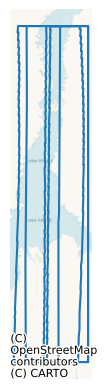

In [10]:
axes = data_frame.to_crs(epsg=3857).boundary.plot()
contextily.add_basemap(axes, source=contextily.providers.CartoDB.Voyager)
axes.set_axis_off()

If you happen to know your item (granule) id, you can fetch that item directly and see it's assets dictionary.

In [11]:
item = next(
    stac_client.search(collections=["satellogic"], ids=[SATELLOGIC_ITEM_ID]).items()
)
item

<Item id=20251123_221219_589_SN41_L1D_SR_MS_333174>

## Download assets

While the STAC API is open, the [CSDA Orders API](https://csdap.earthdata.nasa.gov/api) requires authentication.
You'll use your [Earthdata login](https://urs.earthdata.nasa.gov/) username and password to log in.

In [12]:
username = input("Earthdata username: ")
password = getpass.getpass("Earthdata password: ")

Logging into CSDA creates an access token that encodes your download quotas, among other information.

In [13]:
client = CsdaClient.open(BasicAuth(username=username, password=password))
client.verify()

'Hello shreyniraula, you have a valid token!'

First, let's see how much quota you have.
The example output has very large quotas, because it was run for a developer on the project who has artificially high quotas.

In [14]:
profile = client.profile(username)
rows = []
for vendor in profile.vendors:
    rows.append([vendor.vendor, vendor.quota, vendor.quota_unit])
tabulate.tabulate(rows, headers=["Vendor", "Quota", "Quota unit"], tablefmt="html")

Vendor,Quota,Quota unit
Satellogic,1000000000000,QuotaUnit.filesize
Planet,1000000000000,QuotaUnit.filesize


### For Planet

To create a new order, let's first identify the item ids that we want to order.
For cost-saving, we regularly move "older" data (data that was provided to the program a long time ago) to "cold" storage, meaning that it can't be quickly downloaded.
For this demonstration, we cheat a bit and use an item that we _know_ isn't in cold storage (for now).

In [15]:
item_search = stac_client.search(
    collections=["planet"],
    ids=[PLANET_ITEM_ID],
)
item_collection = item_search.item_collection()
assert len(item_collection) == 1
data_frame = GeoDataFrame.from_features(item_collection.to_dict())
data_frame

,geometry,eo:gsd,datetime,eo:bands,eo:azimuth,pl:updated,pl:provider,pl:strip_id,eo:off_nadir,pl:item_type,...,pl:visible_percent,pl:anomalous_pixels,pl:pixel_resolution,pl:publishing_stage,pl:quality_category,pl:snow_ice_percent,pl:heavy_haze_percent,pl:light_haze_percent,pl:clear_confidence_percent,pl:visible_confidence_percent
0,"POLYGON ((-71.51031 44.08848, -71.56278 43.921...",3.6,2025-07-06T16:05:25.677171Z,[],111.2,2025-07-07T04:02:58Z,planetscope,8175328,1,PSScene,...,88,0,3,standard,test,0,0,35,84,77


The item has several assets.

In [16]:
item = item_collection[0]
rows = []
for key, asset in item.assets.items():
    if file_size := asset.ext.file.size:
        humanized_file_size = humanize.naturalsize(file_size)
    else:
        humanized_file_size = None
    if roles := asset.roles:
        humanized_roles = humanize.natural_list(roles)
    else:
        humanized_roles = roles
    rows.append([key, humanized_roles, asset.media_type, humanized_file_size])
tabulate.tabulate(
    rows, headers=["Key", "Roles", "Type", "File size", "Roles"], tablefmt="html"
)

Key,Roles,Type,File size
thumbnail,thumbnail,,
basic_udm2,data,image/tiff,5.8 MB
ortho_udm2,data,image/tiff,9.3 MB
ortho_visual,data,image/tiff,179.2 MB
json_metadata,metadata,application/json,968 Bytes
basic_analytic_4b,data,image/tiff,367.7 MB
basic_analytic_8b,data,image/tiff,736.6 MB
ortho_analytic_4b,data,image/tiff,518.2 MB
ortho_analytic_8b,data,image/tiff,1.0 GB
ortho_analytic_4b_sr,data,image/tiff,437.1 MB


Let's download the ortho visual asset.

completed download, proceed to visualize


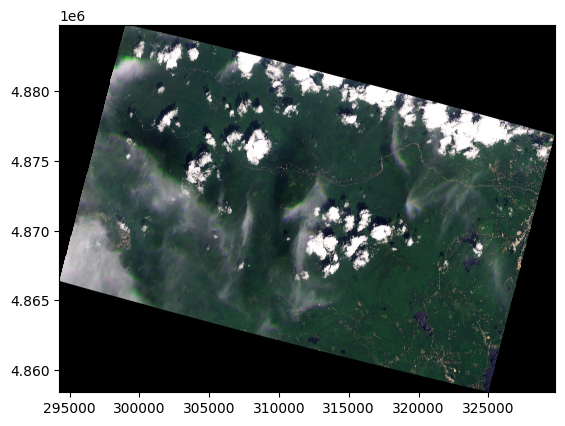

In [17]:
asset_key = "ortho_visual"
with TemporaryDirectory() as temporary_directory:
    local_path = Path(temporary_directory) / f"{asset_key}.tif"
    client.download_item(item, asset_key, local_path)
    print("completed download, proceed to visualize")
    with rasterio.open(local_path) as dataset:
        rasterio.plot.show(dataset)

### For Satellogic

In [18]:
item_search = stac_client.search(
    collections=["satellogic"],
    ids=[SATELLOGIC_ITEM_ID],
)
item_collection = item_search.item_collection()
assert len(item_collection) == 1
data_frame = GeoDataFrame.from_features(item_collection.to_dict())
data_frame

,geometry,gsd,created,license,datetime,platform,proj:epsg,providers,instruments,satl:sat_id,...,eo:cloud_cover,view:off_nadir,satl:outcome_id,view:sun_azimuth,satl:exposure_sec,satl:product_name,view:sun_elevation,satl:product_version,view:incidence_angle,satl:satellite_generation
0,"POLYGON ((-114.39874 36.34958, -114.39903 36.3...",0.5,2025-11-24T04:35:34.631918Z,proprietary,2025-11-23T22:12:19.589151Z,NewSat,32611,"[{'url': 'https://satellogic.com/', 'name': 'S...",[multispectral],newsat41,...,0.0,7.23,6379604c-1579-4f60-8789-948cf8ce3933,222.472,0.006,L1D_SR,21.0,2.0.0,7.959,MarkV


The item has several assets.


In [19]:
item = item_collection[0]
rows = []
for key, asset in item.assets.items():
    if file_size := asset.ext.file.size:
        humanized_file_size = humanize.naturalsize(file_size)
    else:
        humanized_file_size = None
    if roles := asset.roles:
        humanized_roles = humanize.natural_list(roles)
    else:
        humanized_roles = roles
    rows.append([key, humanized_roles, asset.media_type, humanized_file_size])
tabulate.tabulate(
    rows, headers=["Key", "Roles", "Type", "File size", "Roles"], tablefmt="html"
)

Key,Roles,Type,File size
cloud,cloud,application/xml,1.5 kB
visual,data,application/xml,2.7 kB
preview,overview,image/png,16.5 MB
analytic,data,application/xml,3.2 kB
footprint,footprint,application/vnd.google-earth.kml+xml,3.4 kB
thumbnail,thumbnail,image/png,87.1 kB
vrt_cloud,data,image/tiff; application=geotiff,9.3 MB
vrt_visual,data,image/tiff; application=geotiff,1.7 GB
toa-factors,metadata,application/geo+json,183.4 kB
vrt_analytic,data,image/tiff; application=geotiff,5.0 GB


Let's download the vrt_cloud asset.


completed download, proceed to visualize


/Users/sniraula/Documents/Impact/Task/venvs_py_3_12/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


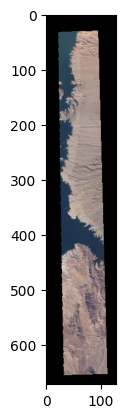

In [22]:
asset_key = "thumbnail"
with TemporaryDirectory() as temporary_directory:
    local_path = Path(temporary_directory) / f"{asset_key}.png"
    client.download_item(item, asset_key, local_path)
    print("completed download, proceed to visualize")
    with rasterio.open(local_path) as dataset:
        rasterio.plot.show(dataset)